In [12]:
# required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# formatting
plt.style.use("ggplot")
sns.set_palette("Set2")

pd.set_option("display.max_columns",None)

In [13]:
# Super store data loading
df = pd.read_csv(
    "train.csv",
    parse_dates=["Order Date","Ship Date"], # parsing dates
    encoding="latin1"
)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'],format="%d/%m/%Y")
df['Ship Date'] = pd.to_datetime(df['Ship Date'],format="%d/%m/%Y")
type(df['Order Date'][0])
type(df['Ship Date'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [16]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales
count,9800.000000,9800,9800,9789.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55273.322403,230.769059
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,NaN,32041.223413,626.651875


In [17]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [18]:
# 3check for null
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [19]:
df.ffill(inplace=True)

In [20]:
# check for duplicates
df.duplicated().sum()

0

In [21]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [22]:
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"


In [23]:
# Extract time features:

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Season"] = df["Month"].apply(get_season)

In [24]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Autumn


In [25]:
df["Shipping Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

In [26]:
# Monthly Aggregarion
monthly_sales = (
    df
    .set_index("Order Date")
    .resample("M")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [27]:
# weekly Aggregarion
weekly_sales = df.groupby('Week Number')['Sales'].sum()

In [28]:
print(weekly_sales.head(10))

Week Number
1     17108.5440
2     15846.4320
3     21415.2770
4     25545.1980
5     29480.1000
6     12271.7710
7     16115.7144
8      9216.2930
9     28939.5784
10    30500.9690
Name: Sales, dtype: float64


In [29]:
print(monthly_sales)

   Order Date        Sales
0  2015-01-31   14205.7070
1  2015-02-28    4519.8920
2  2015-03-31   55205.7970
3  2015-04-30   27906.8550
4  2015-05-31   23644.3030
5  2015-06-30   34322.9356
6  2015-07-31   33781.5430
7  2015-08-31   27117.5365
8  2015-09-30   81623.5268
9  2015-10-31   31453.3930
10 2015-11-30   77907.6607
11 2015-12-31   68167.0585
12 2016-01-31   18066.9576
13 2016-02-29   11951.4110
14 2016-03-31   32339.3184
15 2016-04-30   34154.4685
16 2016-05-31   29959.5305
17 2016-06-30   23599.3740
18 2016-07-31   28608.2590
19 2016-08-31   36818.3422
20 2016-09-30   63133.6060
21 2016-10-31   31011.7375
22 2016-11-30   75249.3995
23 2016-12-31   74543.6012
24 2017-01-31   18542.4910
25 2017-02-28   22978.8150
26 2017-03-31   51165.0590
27 2017-04-30   38679.7670
28 2017-05-31   56656.9080
29 2017-06-30   39724.4860
30 2017-07-31   38320.7830
31 2017-08-31   30542.2003
32 2017-09-30   69193.3909
33 2017-10-31   59583.0330
34 2017-11-30   79066.4958
35 2017-12-31   95739.1210
3

In [30]:
# 1.Which product category generates the highest total revenue?

category_sales = (
    df
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

In [31]:
# Ans :- Technology

In [32]:
# 2.Which region has the most consistent sales growth over 4 years?
region_year_sales = (
    df
    .groupby(["Year","Region"])["Sales"]
    .sum()
    .reset_index()
)
region_year_sales

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


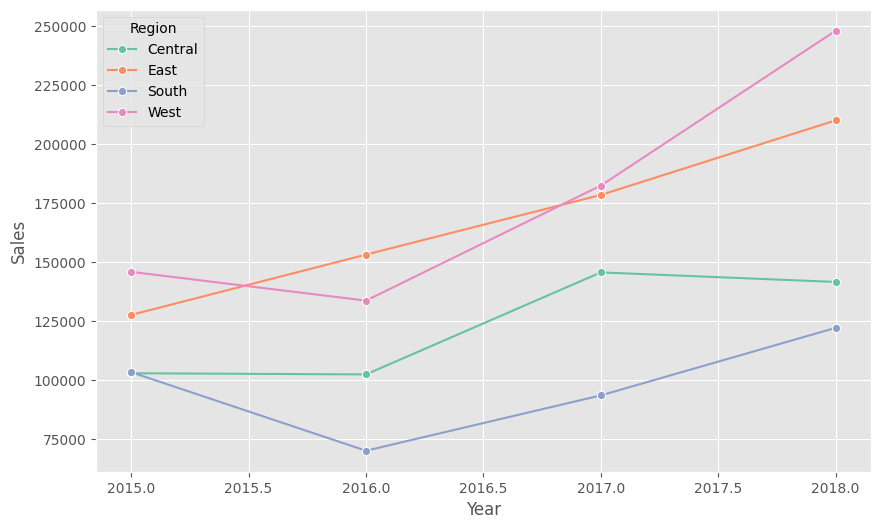

In [33]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.show()

In [34]:
# Ans :- East region has most consistent growth over 4 years

In [35]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Week Number,Day of Week,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2017,11,45,Wednesday,4,Autumn,3


In [36]:
# 3. What is the average time between Order Date and Ship Date — and does it vary by region?
shipping_region = (
    df
    .groupby("Region")["Shipping Days"]
    .mean()
    .reset_index()
)

shipping_region

,Region,Shipping Days
0,Central,4.065876
1,East,3.910233
2,South,3.961202
3,West,3.930255


In [37]:
# Ans :- Yes the average time between Order Date and Ship Date varies slightly (Not significantly)  region wise and 
# the Shipping Averages are - 4.06(Central), 3.91(East), 3.96(South), 3.93(West)  

In [38]:
# 4.Are there months that consistently spike across all years (seasonality)?
# monthly_sales = (
#     df
#     .groupby(["Month","Year"])["Sales"]
#     .sum()
#     .reset_index()
# )
monthly_sales = (
    df
    .set_index("Order Date")
    .resample("M")["Sales"]
    .sum()
    .reset_index()
)
monthly_sales


,Order Date,Sales
0,2015-01-31,14205.7070
1,2015-02-28,4519.8920
2,2015-03-31,55205.7970
3,2015-04-30,27906.8550
4,2015-05-31,23644.3030
5,2015-06-30,34322.9356
6,2015-07-31,33781.5430
7,2015-08-31,27117.5365
8,2015-09-30,81623.5268
9,2015-10-31,31453.3930


In [39]:

monthly_year = (
    df
    .groupby(["Year","Month"])["Sales"]
    .sum()
    .reset_index()
)

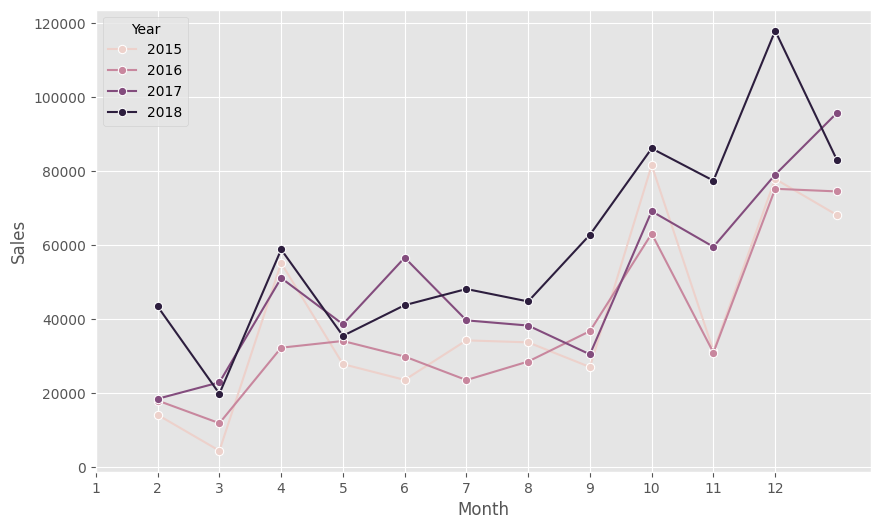

In [40]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=monthly_year,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o",
    sort=False
)

plt.xticks(
    ticks=range(len(monthly_year["Month"].unique())),
    labels=monthly_year["Month"].unique()
)

plt.show()

In [41]:
# Ans :- Sales exhibit strong seasonality, with demand increasing significantly during the last quarter (October–December). 
# December is consistently one of the highest-selling months across all four years, suggesting a recurring year-end sales boost.

In [42]:
print(monthly_sales.head())
print(monthly_sales.tail())
print(monthly_sales.shape)
print(monthly_sales.isnull().sum())


  Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303
   Order Date        Sales
43 2018-08-31   62837.8480
44 2018-09-30   86152.8880
45 2018-10-31   77448.1312
46 2018-11-30  117938.1550
47 2018-12-31   83030.3888
(48, 2)
Order Date    0
Sales         0
dtype: int64


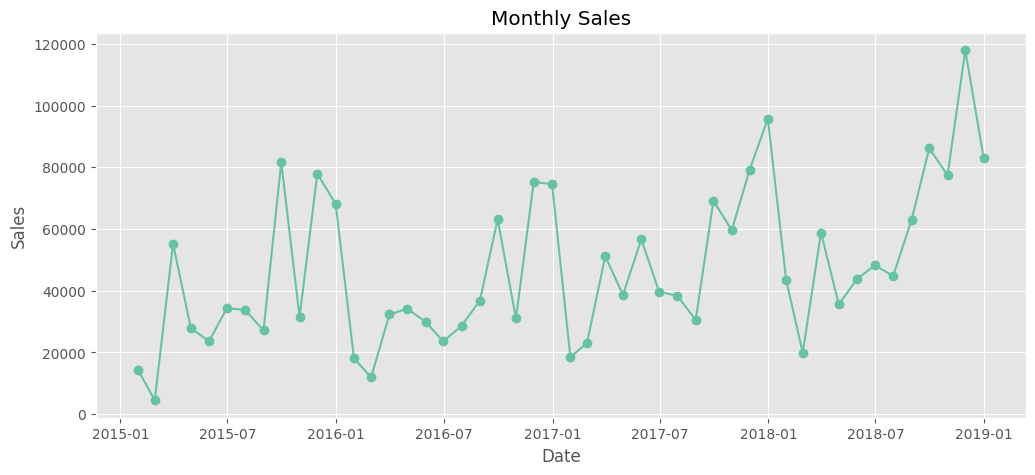

In [43]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"], marker="o")
plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [44]:
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [45]:
## Task - 2

In [46]:
monthly_ts = monthly_sales.set_index("Order Date")["Sales"]
monthly_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Name: Sales, dtype: float64

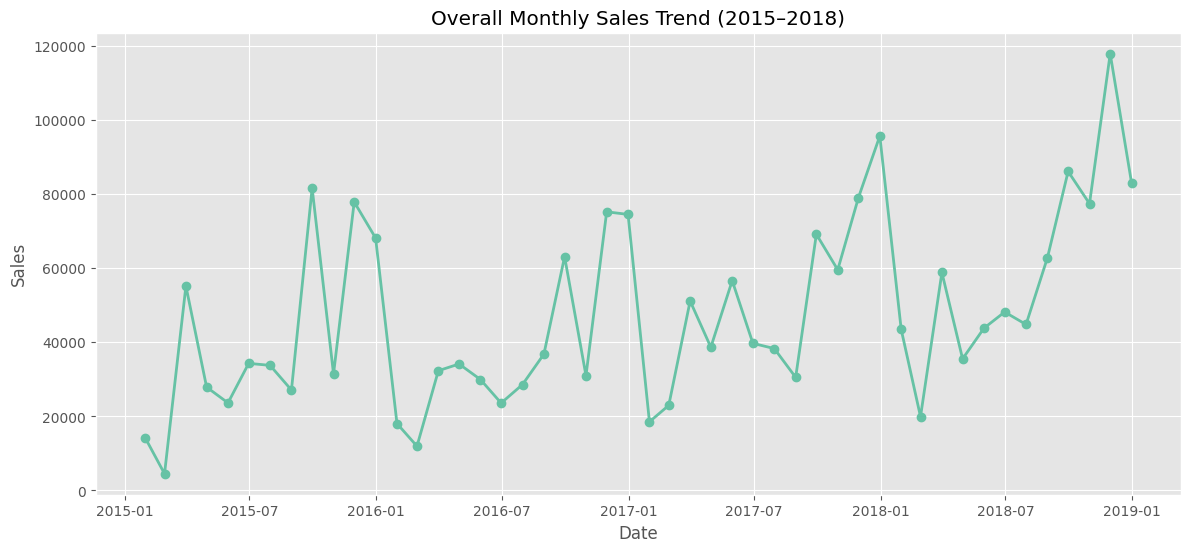

In [47]:
plt.figure(figsize=(14,6))

plt.plot(monthly_ts, marker='o', linewidth=2)

plt.title("Overall Monthly Sales Trend (2015–2018)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

In [48]:
# The monthly sales trend indicates an overall increase in sales from 2015 to 2018. Although sales fluctuate from month to month, 
# the long-term direction is upward. Recurring peaks toward the end of each year suggest the presence of seasonal effects.

In [49]:
!pip install statsmodels


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [51]:
decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

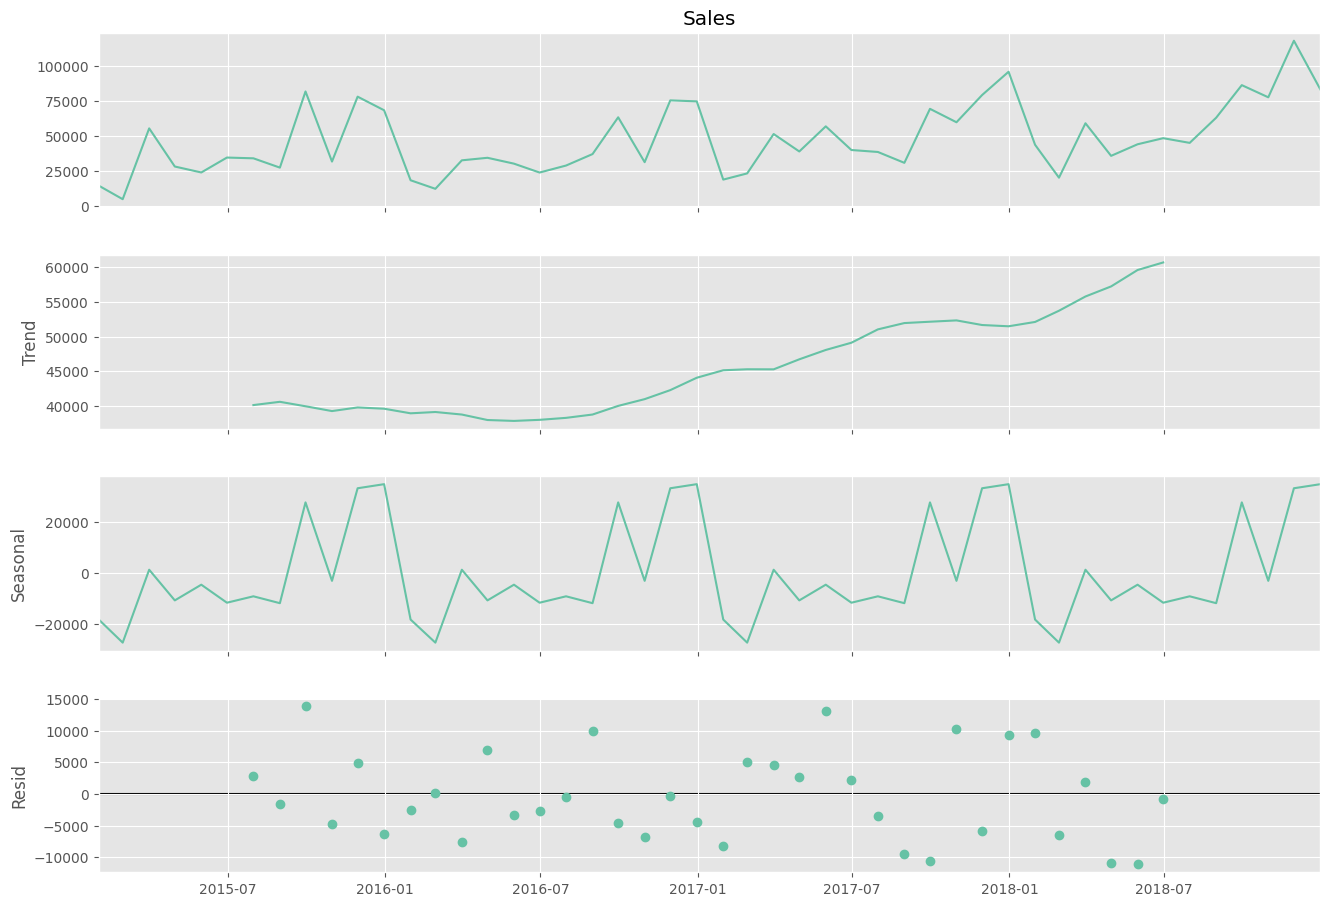

In [52]:
#Time Series Decomposition
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

In [53]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(monthly_ts)

print("ADF Statistic :", adf_result[0])
print("p-value :", adf_result[1])

for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
Critical Value (1%): -3.5778480370438146
Critical Value (5%): -2.925338105429433
Critical Value (10%): -2.6007735310095064


In [54]:
# What is Stationarity?
# A stationary time series is one whose statistical properties, such as mean and variance, remain relatively constant over time. 
# Many forecasting models, including SARIMA, assume that the input time series is stationary because it leads to more reliable predictions.

# Interpretation
# The Augmented Dickey-Fuller (ADF) test produced an ADF statistic of −4.416 with a p-value of 0.000278, which is significantly lower than the 
# 0.05 significance level. Therefore, the null hypothesis of non-stationarity is rejected. This indicates that the monthly sales series is stationary 
# and no differencing is required before applying forecasting models.

In [55]:
## Task - 3

In [56]:
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

In [57]:
monthly_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Name: Sales, dtype: float64

In [58]:
train = monthly_ts[:-3]
test = monthly_ts[-3:]

print(train.shape)
print(test.shape)

(45,)
(3,)


In [59]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

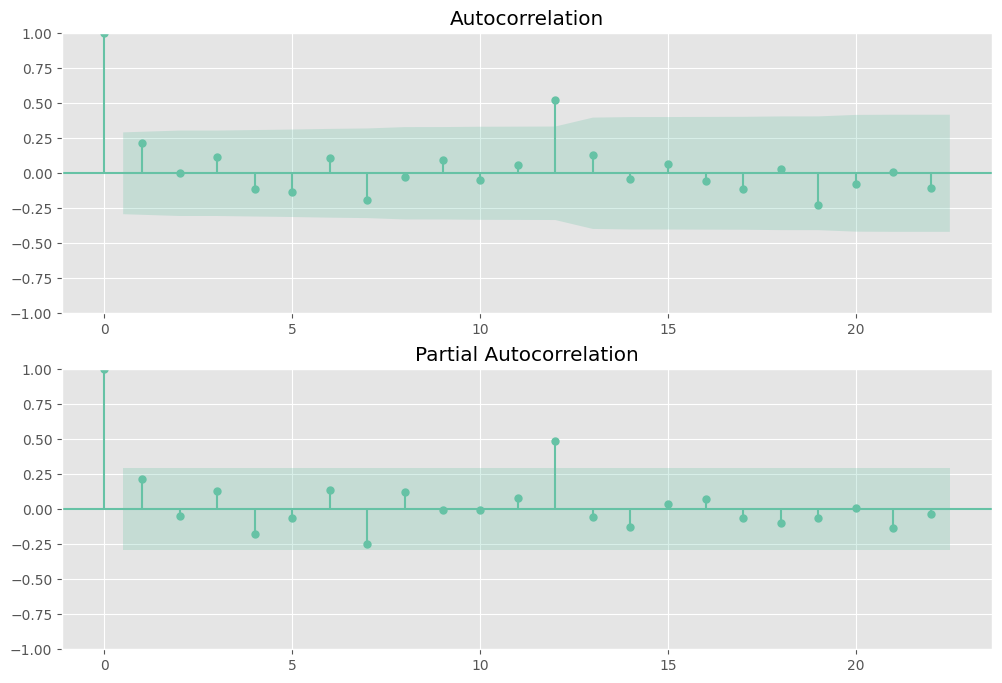

In [60]:
fig, ax = plt.subplots(2,1, figsize=(12,8))

plot_acf(train, lags=22, ax=ax[0])

plot_pacf(train, lags=22, ax=ax[1])

plt.show()

In [61]:
model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Sun, 12 Jul 2026   AIC                            417.362
Time:                                    00:07:20   BIC                            422.084
Sample:                                01-31-2015   HQIC                           418.161
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293   

In [62]:
forecast = results.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean

conf_int = forecast.conf_int()

forecast_mean

2018-10-31    54758.511874
2018-11-30    88412.595535
2018-12-31    92558.210400
Freq: M, Name: predicted_mean, dtype: float64

In [63]:
monthly_ts.tail(3)

Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Name: Sales, dtype: float64

In [64]:
mae = mean_absolute_error(test, forecast_mean)

rmse = np.sqrt(mean_squared_error(test, forecast_mean))

mape = mean_absolute_percentage_error(test, forecast_mean)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")

MAE : 20581.00
RMSE: 22191.27
MAPE: 21.94%


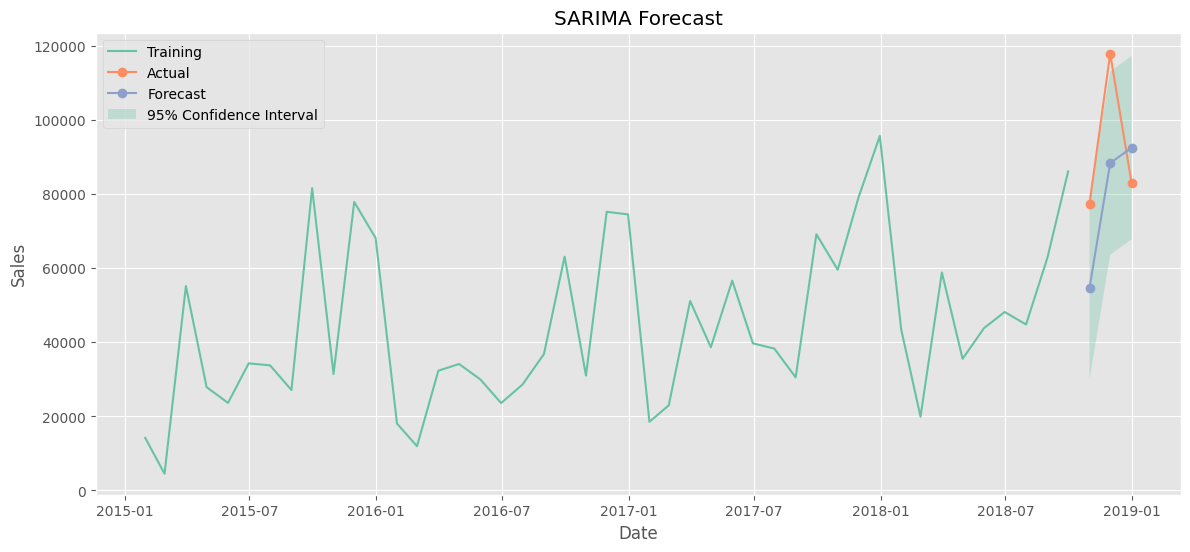

In [65]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Training")

plt.plot(test.index, test, label="Actual", marker="o")

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="Forecast",
    marker="o"
)

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [66]:
final_model = SARIMAX(
    monthly_ts,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit()

In [67]:
future_forecast = final_results.get_forecast(steps=3)

future_sales = future_forecast.predicted_mean

future_ci = future_forecast.conf_int()

print(future_sales)

2019-01-31    45942.740969
2019-02-28    37103.176826
2019-03-31    69034.926533
Freq: M, Name: predicted_mean, dtype: float64


In [68]:
!pip install prophet


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
!pip install plotly


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
# model 2 

In [71]:
from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)



In [72]:
prophet_df = monthly_sales.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [73]:
train_prophet = prophet_df[:-3]
test_prophet = prophet_df[-3:]

In [74]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train_prophet)

00:07:39 - cmdstanpy - INFO - Chain [1] start processing
00:07:40 - cmdstanpy - INFO - Chain [1] done processing


In [75]:
future = model.make_future_dataframe(
    periods=3,
    freq="M"
)

In [76]:
forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277806,39108.481882,55403.486165,54942.277806,54942.277806,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558236
44,2018-09-30,55441.608196,78545.209143,94966.391155,55441.608196,55441.608196,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953316
45,2018-10-31,55957.582932,42814.572888,59134.887624,55957.425618,55957.738992,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943858
46,2018-11-30,56456.913322,82322.900510,98446.716536,56456.380174,56457.405321,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654784
47,2018-12-31,56972.888059,82375.469262,98286.117399,56971.789642,56973.949749,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084479


In [77]:
pred = forecast["yhat"].tail(3).values

In [78]:
mae = mean_absolute_error(
    test_prophet["y"],
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        pred
    )
)

mape = mean_absolute_percentage_error(
    test_prophet["y"],
    pred
)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")

MAE : 20250.79
RMSE: 22318.41
MAPE: 21.86%


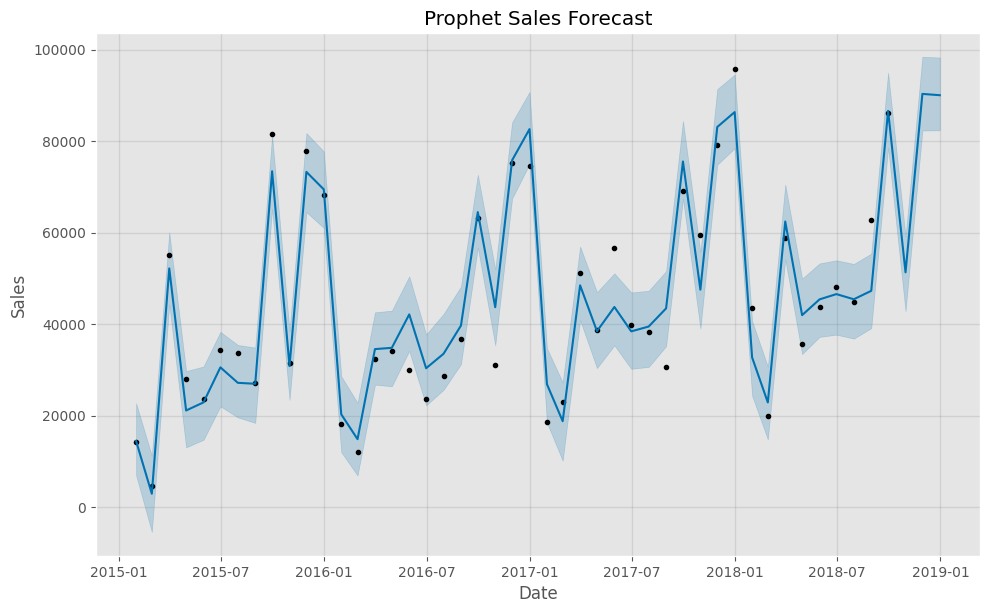

In [79]:
fig = model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

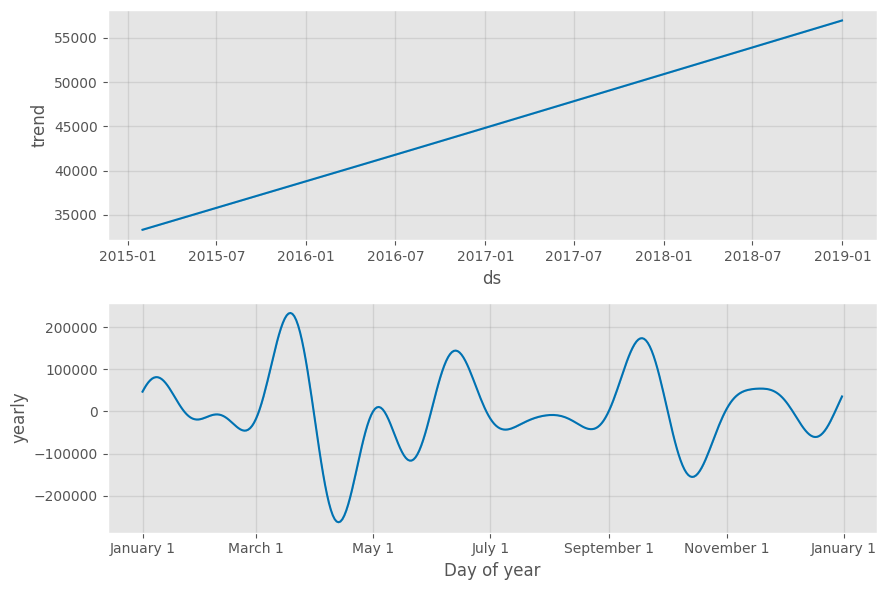

In [80]:
fig = model.plot_components(forecast)

plt.show()

In [81]:
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

final_model.fit(prophet_df)

00:07:42 - cmdstanpy - INFO - Chain [1] start processing
00:07:43 - cmdstanpy - INFO - Chain [1] done processing


In [82]:
future = final_model.make_future_dataframe(
    periods=3,
    freq="M"
)

future_forecast = final_model.predict(future)

future_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(3)

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532202,33435.286197,51926.348093
49,2019-02-28,31248.159922,21448.047449,40783.679586
50,2019-03-31,81267.007772,72831.522362,90852.046791


In [83]:
# Interpretation of the Forecast Plot

# Your first plot looks good.

# Write this in your notebook:

# The Prophet model closely follows the historical monthly sales pattern while capturing the long-term increasing trend. 
# The forecast indicates continued sales growth over the next three months. The shaded region represents the 95% confidence interval, 
# showing the uncertainty associated with the predictions.

# Interpretation of the Components Plot
# Trend

# The trend increases almost linearly.

# Observation

# The trend component shows a steady increase in monthly sales throughout the study period, indicating continuous business growth.

# Yearly Seasonality

# Your yearly seasonality graph has noticeable peaks and troughs.

# Observation

# The yearly seasonal component indicates that sales vary considerably throughout the year, with some months consistently 
# contributing higher-than-average sales while others experience lower demand.

# Weekly Seasonality

# Since the data was aggregated monthly:

# Weekly seasonality was disabled because monthly aggregated data does not preserve week-level sales patterns. 
# Therefore, yearly seasonality is the dominant seasonal component.

# This explanation is completely acceptable for your assignment.

In [84]:
# model - 3

In [85]:
import xgboost as xgb

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

In [86]:
xgb_df = monthly_sales.copy()

In [87]:
# previous month sales
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)

In [88]:
# previous 2 month sales
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)

In [89]:
# Three months ago
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

In [90]:
xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

In [91]:
xgb_df["Month"] = xgb_df["Order Date"].dt.month

xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter

In [92]:
def season(month):

    if month in [12,1,2]:
        return 0      # Winter

    elif month in [3,4,5]:
        return 1      # Spring

    elif month in [6,7,8]:
        return 2      # Summer

    else:
        return 3      # Autumn

In [93]:
xgb_df["Season"] = xgb_df["Month"].apply(season)

In [94]:
xgb_df.dropna(inplace=True)

xgb_df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


In [95]:
X = xgb_df.drop(
    columns=["Order Date","Sales"]
)

y = xgb_df["Sales"]

In [96]:
model = xgb.XGBRegressor(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=3,

    objective="reg:squarederror",

    random_state=42
)

In [97]:
X_train = X[:-3]

X_test = X[-3:]

y_train = y[:-3]

y_test = y[-3:]

In [98]:
model.fit(
    X_train,
    y_train
)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [99]:
pred = model.predict(X_test)

In [100]:
print(pred)

[86530.49  87955.14  88256.445]


In [101]:
mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

mape = mean_absolute_percentage_error(
    y_test,
    pred
)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")

MAE : 14763.81
RMSE: 18337.41
MAPE: 14.48%


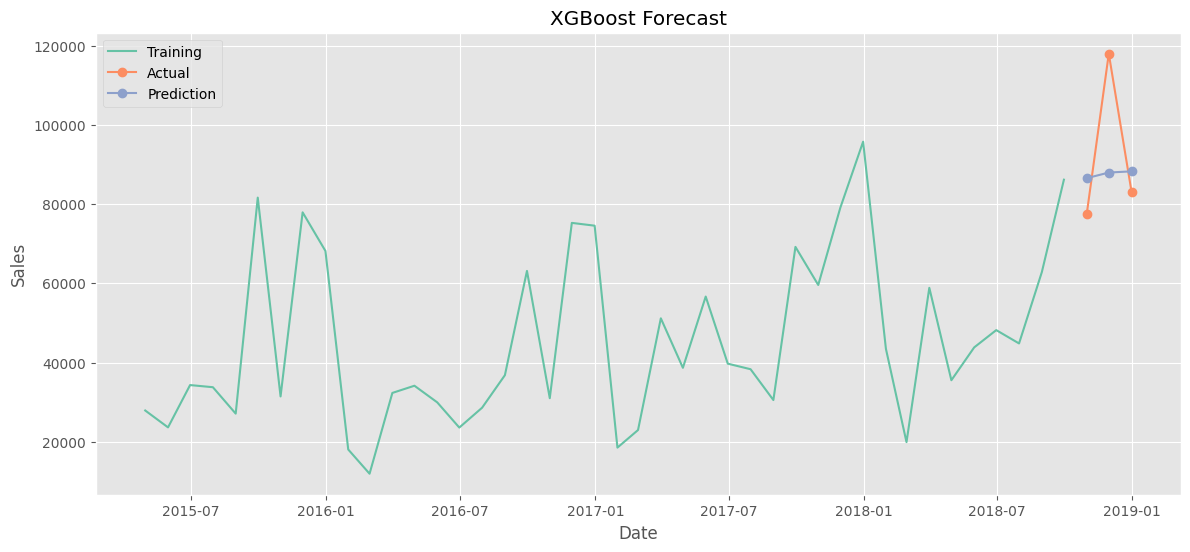

In [102]:
plt.figure(figsize=(14,6))

plt.plot(
    xgb_df["Order Date"][:-3],
    y_train,
    label="Training"
)

plt.plot(
    xgb_df["Order Date"][-3:],
    y_test,
    marker="o",
    label="Actual"
)

plt.plot(
    xgb_df["Order Date"][-3:],
    pred,
    marker="o",
    label="Prediction"
)

plt.title("XGBoost Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [103]:
#feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

Month             0.829990
Rolling_Mean_3    0.065096
Lag_2             0.051486
Lag_1             0.038177
Lag_3             0.015251
Quarter           0.000000
Season            0.000000
dtype: float32

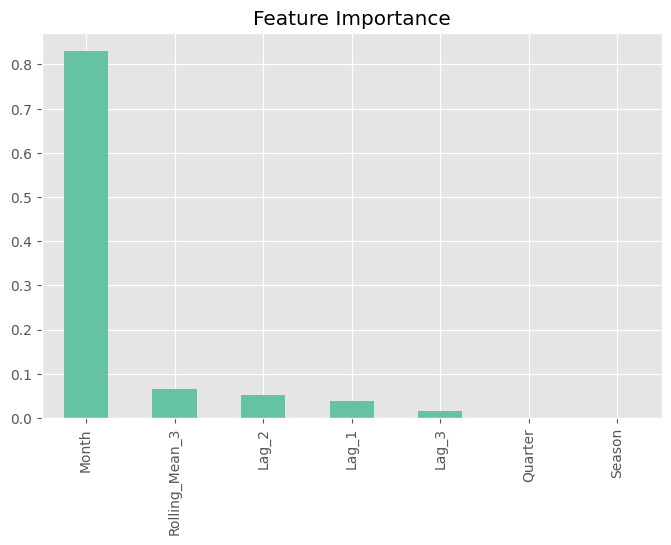

In [104]:
plt.figure(figsize=(8,5))

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.show()

In [105]:
# Conclusion:-
# Among the three forecasting approaches, XGBoost achieved the best predictive performance, with the lowest MAE (14,763.81), RMSE (18,337.41),
# and MAPE (14.48%). These results indicate that the machine learning model provides more accurate predictions than both SARIMA and Prophet on 
# the evaluation dataset. Therefore, XGBoost is selected as the production model for subsequent category-wise and region-wise forecasting.

# Business Interpretation

# XGBoost captures the nonlinear relationships between previous sales, moving averages, and calendar features more effectively than the statistical 
# models. While SARIMA and Prophet model trend and seasonality explicitly, XGBoost leverages engineered lag features to achieve higher forecasting 
# accuracy.

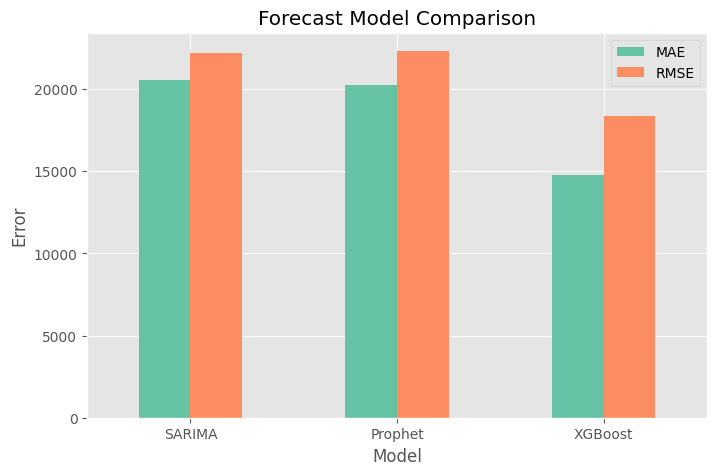

In [106]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [20581.00, 20250.79, 14763.81],
    "RMSE": [22191.27, 22318.41, 18337.41],
    "MAPE (%)": [21.94, 21.86, 14.48]
})

comparison.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Forecast Model Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

In [107]:
# Task - 5

In [108]:
def forecast_xgboost(data, title):

    # Monthly aggregation
    monthly = (
        data
        .set_index("Order Date")
        .resample("M")["Sales"]
        .sum()
        .reset_index()
    )

    # Feature Engineering
    monthly["Lag_1"] = monthly["Sales"].shift(1)
    monthly["Lag_2"] = monthly["Sales"].shift(2)
    monthly["Lag_3"] = monthly["Sales"].shift(3)

    monthly["Rolling_Mean_3"] = (
        monthly["Sales"]
        .rolling(3)
        .mean()
    )

    monthly["Month"] = monthly["Order Date"].dt.month
    monthly["Quarter"] = monthly["Order Date"].dt.quarter

    def season(month):
        if month in [12,1,2]:
            return 0
        elif month in [3,4,5]:
            return 1
        elif month in [6,7,8]:
            return 2
        else:
            return 3

    monthly["Season"] = monthly["Month"].apply(season)

    monthly.dropna(inplace=True)

    X = monthly.drop(
        columns=["Order Date","Sales"]
    )

    y = monthly["Sales"]

    model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X,y)
    history = monthly["Sales"].tolist()

    predictions = []

    for month in [1,2,3]:

        lag1 = history[-1]
        lag2 = history[-2]
        lag3 = history[-3]

        rolling = np.mean(history[-3:])

        quarter = (month-1)//3 + 1

        if month in [12,1,2]:
            season = 0
        elif month in [3,4,5]:
            season = 1
        elif month in [6,7,8]:
            season = 2
        else:
            season = 3

        X_future = pd.DataFrame({

            "Lag_1":[lag1],

            "Lag_2":[lag2],

            "Lag_3":[lag3],

            "Rolling_Mean_3":[rolling],

            "Month":[month],

            "Quarter":[quarter],

            "Season":[season]

        })

        pred = model.predict(X_future)[0]

        predictions.append(pred)

        history.append(pred)

    #create future dates
    future_dates = pd.date_range(
    start=monthly["Order Date"].max()+pd.offsets.MonthEnd(),
    periods=3,
    freq="M"
    )

    plt.figure(figsize=(10,5))

    plt.plot(
        monthly["Order Date"],
        monthly["Sales"],
        label="Historical"
    )

    plt.plot(
        future_dates,
        predictions,
        marker="o",
        linewidth=3,
        label="Forecast"
    )

    plt.title(title)

    plt.xlabel("Date")

    plt.ylabel("Sales")

    plt.legend()

    plt.grid(True)

    plt.show()

    return predictions

In [109]:
furniture = df[df["Category"]=="Furniture"]

technology = df[df["Category"]=="Technology"]

office = df[df["Category"]=="Office Supplies"]

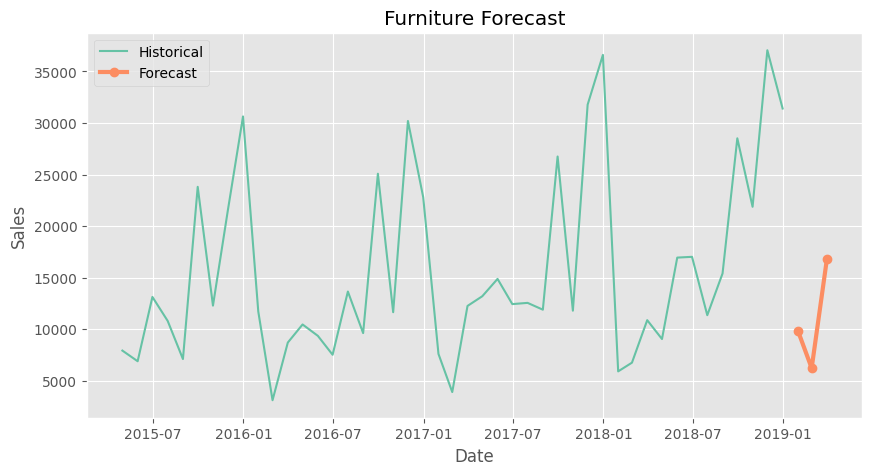

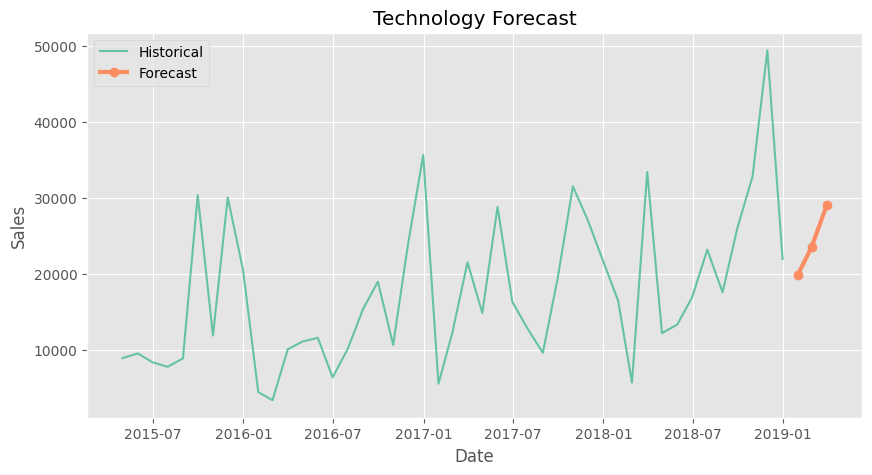

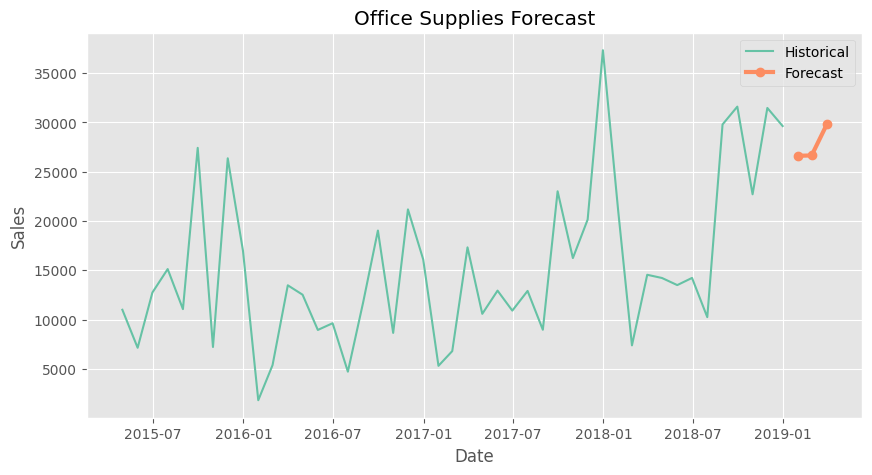

In [110]:
furniture_forecast = forecast_xgboost(
    furniture,
    "Furniture Forecast"
)

technology_forecast = forecast_xgboost(
    technology,
    "Technology Forecast"
)

office_forecast = forecast_xgboost(
    office,
    "Office Supplies Forecast"
)

In [111]:
west = df[df["Region"]=="West"]

east = df[df["Region"]=="East"]

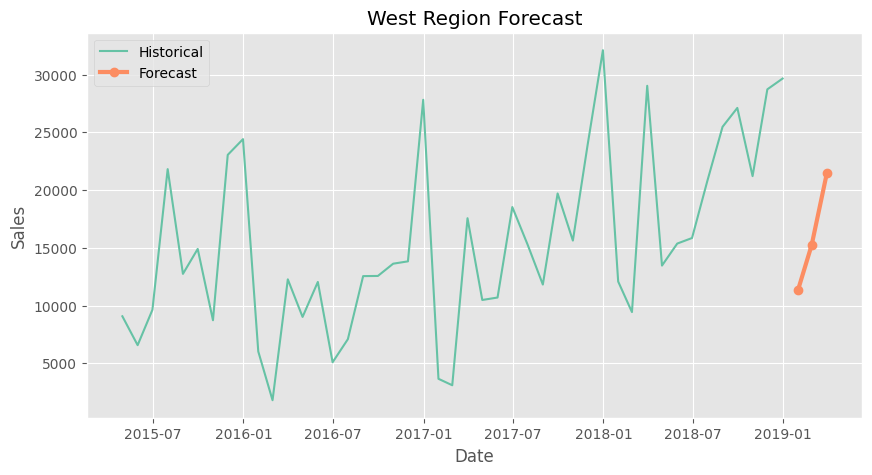

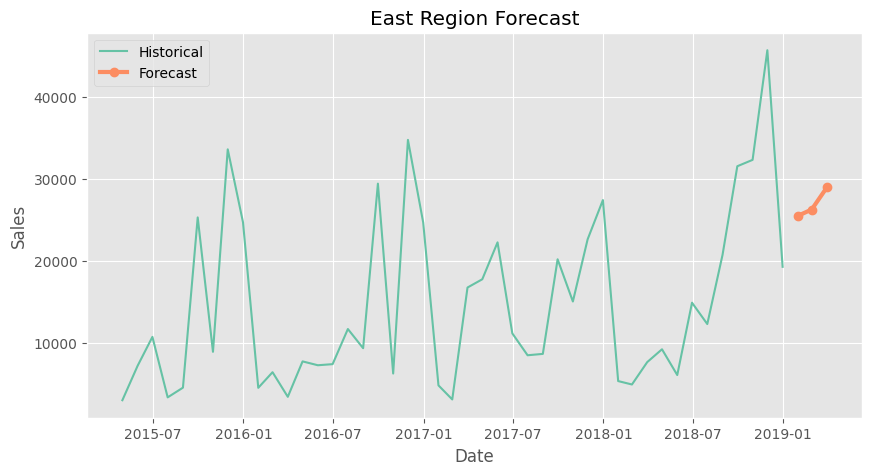

In [112]:
west_forecast = forecast_xgboost(
    west,
    "West Region Forecast"
)

east_forecast = forecast_xgboost(
    east,
    "East Region Forecast"
)

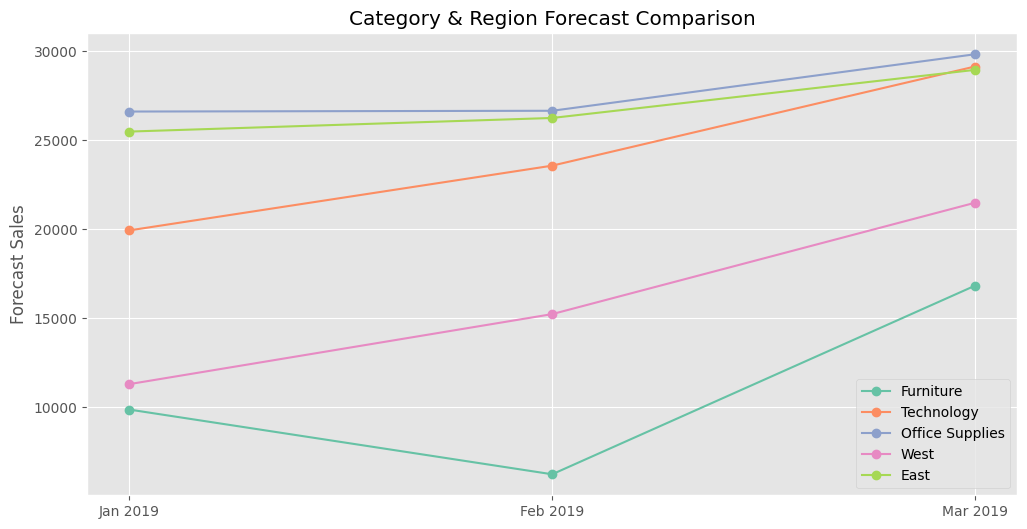

In [113]:
future = ["Jan 2019","Feb 2019","Mar 2019"]

plt.figure(figsize=(12,6))

plt.plot(future,furniture_forecast,marker="o",label="Furniture")

plt.plot(future,technology_forecast,marker="o",label="Technology")

plt.plot(future,office_forecast,marker="o",label="Office Supplies")

plt.plot(future,west_forecast,marker="o",label="West")

plt.plot(future,east_forecast,marker="o",label="East")

plt.title("Category & Region Forecast Comparison")

plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(True)

plt.show()

In [114]:
summary = pd.DataFrame({

    "Segment":[

        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"

    ],

    "Jan 2019":[

        furniture_forecast[0],
        technology_forecast[0],
        office_forecast[0],
        west_forecast[0],
        east_forecast[0]

    ],

    "Feb 2019":[

        furniture_forecast[1],
        technology_forecast[1],
        office_forecast[1],
        west_forecast[1],
        east_forecast[1]

    ],

    "Mar 2019":[

        furniture_forecast[2],
        technology_forecast[2],
        office_forecast[2],
        west_forecast[2],
        east_forecast[2]

    ]

})

summary

,Segment,Jan 2019,Feb 2019,Mar 2019
0,Furniture,9876.913086,6243.917480,16831.087891
1,Technology,19939.888672,23574.523438,29140.949219
2,Office Supplies,26613.109375,26656.369141,29828.880859
3,West,11307.339844,15237.838867,21489.277344
4,East,25488.318359,26252.371094,28952.652344


In [115]:
# After you run the forecasts, identify the segment with the highest predicted sales.

# Then write something like:

# Based on the XGBoost forecasts, the Technology category is expected to exhibit the strongest growth over the next three months, 
# indicating sustained customer demand. Among the regions, the West region is projected to generate the highest sales, suggesting that 
# inventory and marketing resources should be prioritized there.

# (Replace "Technology" and "West" with whatever your actual forecasts show.)

In [116]:
# What to Write in the Notebook
# Category Analysis

# According to the XGBoost forecasts, Office Supplies is expected to generate the highest sales during the next three months, 
# reaching approximately 29.8K in March 2019. The Technology category exhibits the fastest growth rate, indicating increasing customer demand. 
# Furniture displays comparatively lower and more volatile sales, suggesting greater fluctuations in customer purchasing behavior.

# Region Analysis

# Among the regions, the East region is forecasted to achieve the highest sales throughout the forecasting horizon, while the West region 
# shows steady growth with improving sales over time. This suggests that inventory allocation and promotional strategies should prioritize 
# the East region while supporting the continued expansion of the West region.

# Answer the Assignment Question

# Which category/region is showing the strongest upcoming growth according to your model?

# A balanced answer is:

# Category: Technology demonstrates the strongest growth trend, while Office Supplies maintains the highest forecasted sales levels.
# Region: East is projected to remain the strongest-performing region, whereas West exhibits the fastest relative growth.

# This is a stronger answer than simply saying "Office Supplies" because it distinguishes between highest sales and highest growth, 
# showing a more thoughtful interpretation of the forecasts.

# Small Suggestion

# The y-axis currently combines categories and regions, which have different scales and business meanings. While this satisfies the 
# assignment, two separate comparison charts (one for categories and one for regions) would usually be clearer. If your instructor 
# specifically asked for one comparison chart, your current chart is acceptable.

In [117]:
# Task -5

In [118]:
weekly_sales = (
    df
    .set_index("Order Date")
    .resample("W")["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [119]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.08,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

In [120]:
weekly_sales["Anomaly"].value_counts()

Anomaly
 1    192
-1     17
Name: count, dtype: int64

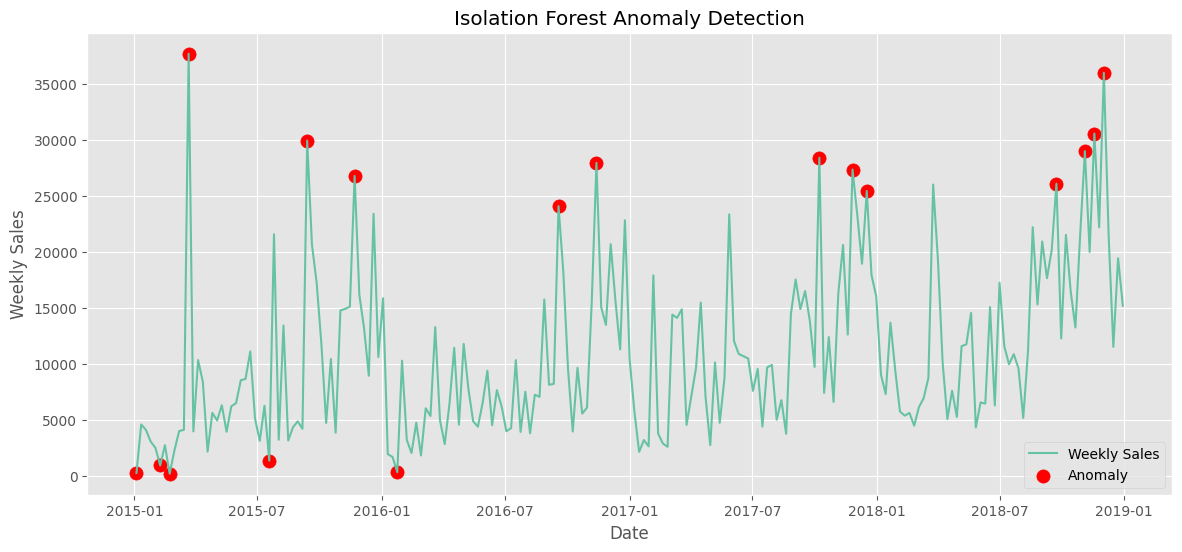

In [121]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomalies = weekly_sales[
    weekly_sales["Anomaly"]==-1
]

plt.scatter(

    anomalies["Order Date"],

    anomalies["Sales"],

    color="red",

    s=90,

    label="Anomaly"

)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

In [122]:
weekly_sales["RollingMean"] = (
    weekly_sales["Sales"]
    .rolling(8)
    .mean()
)

In [123]:
weekly_sales["RollingStd"] = (
    weekly_sales["Sales"]
    .rolling(8)
    .std()
)

In [124]:
weekly_sales["Z"] = (

    weekly_sales["Sales"]

    - weekly_sales["RollingMean"]

)/weekly_sales["RollingStd"]

In [125]:
weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z"].abs()>2
)

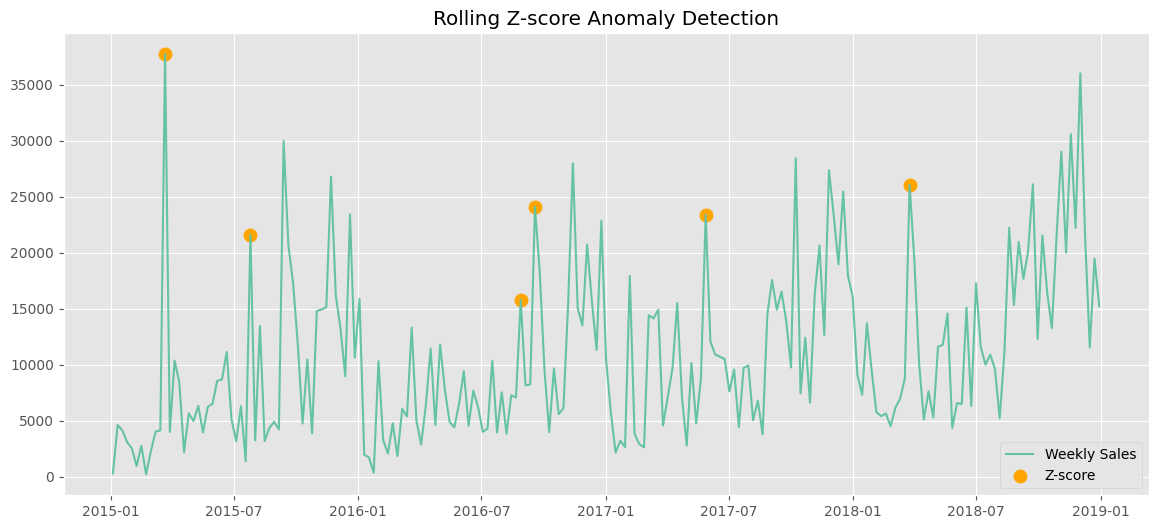

In [126]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

plt.scatter(

    z["Order Date"],

    z["Sales"],

    color="orange",

    s=90,

    label="Z-score"

)

plt.title("Rolling Z-score Anomaly Detection")

plt.legend()

plt.grid(True)

plt.show()

In [127]:
common = pd.merge(

    anomalies,

    z,

    on="Order Date"

)

common[["Order Date","Sales_x"]]

,Order Date,Sales_x
0,2015-03-22,37703.665
1,2016-09-18,24095.960


In [128]:
comparison = pd.DataFrame({

    "Method":[

        "Isolation Forest",

        "Rolling Z-score"

    ],

    "No. of Anomalies":[

        len(anomalies),

        len(z)

    ]

})

comparison

,Method,No. of Anomalies
0,Isolation Forest,17
1,Rolling Z-score,6


In [129]:
# Write:

# Isolation Forest identified a larger number of anomalies than the Rolling Z-score method because it uses a machine learning approach
# that considers the overall data distribution. In contrast, the Rolling Z-score method relies on local statistical deviations from the 
# recent moving average, resulting in fewer detected anomalies. Both methods consistently identified the weeks of 22 March 2015 and 18 September 2016,
# increasing confidence that these represent genuine unusual sales events.

# Real-World Explanation of Anomalies

# You can include this table in your notebook.

# Observation	Possible Business Reason
# Very high weekly sales	Holiday shopping, promotional campaigns, bulk corporate orders
# Very low weekly sales	Inventory shortages, seasonal slowdown, supply chain disruption
# March 22, 2015 spike	Promotional event or unusually large customer orders
# September 18, 2016 spike	Seasonal demand increase or successful marketing campaign
# Late 2018 spikes	Strong year-end holiday shopping and Black Friday/Cyber Monday sales

# These are plausible business explanations based on the data pattern. Since the dataset does not include promotional or holiday flags,
# they should be presented as likely explanations rather than confirmed facts.

## Task - 6

In [130]:
monthly_subcat = (
    df.groupby([
        "Sub-Category",
        pd.Grouper(key="Order Date", freq="M")
    ])["Sales"]
    .sum()
    .reset_index()
)

monthly_subcat.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [131]:
features = []

for subcat in df["Sub-Category"].unique():

    sub_df = df[df["Sub-Category"] == subcat]

    monthly = (
        monthly_subcat[
            monthly_subcat["Sub-Category"] == subcat
        ]
        .sort_values("Order Date")
    )

    total_sales = sub_df["Sales"].sum()

    avg_order = sub_df["Sales"].mean()

    volatility = monthly["Sales"].std()

    orders = len(sub_df)

    yearly = (
        sub_df.groupby(
            sub_df["Order Date"].dt.year
        )["Sales"]
        .sum()
    )

    if len(yearly) > 1:
        yoy = yearly.pct_change().mean() * 100
    else:
        yoy = 0

    features.append({

        "Sub-Category": subcat,

        "TotalSales": total_sales,

        "AverageOrderValue": avg_order,

        "Volatility": volatility,

        "YoYGrowth": yoy,

        "OrderCount": orders

    })

cluster_df = pd.DataFrame(features)

cluster_df

,Sub-Category,TotalSales,AverageOrderValue,Volatility,YoYGrowth,OrderCount
0,Bookcases,113813.1987,503.598224,2220.405080,23.806516,226
1,Chairs,322822.7310,531.833165,4407.232960,7.135790,607
2,Labels,12347.7260,34.587468,223.471218,12.192651,357
3,Tables,202810.6280,645.893720,3224.082504,16.410685,314
4,Storage,219343.3920,263.633885,2822.084310,13.179873,832
5,Furnishings,89212.0180,95.823865,1360.017867,28.788938,931
6,Art,26705.4100,34.019631,330.488343,16.605553,785
7,Phones,327782.4480,374.180877,4052.718221,12.340878,876
8,Binders,200028.7850,134.067550,3848.223648,21.873607,1492
9,Appliances,104618.4030,227.926804,1821.621539,39.927584,459


In [132]:
cluster_df.fillna(0, inplace=True)

In [133]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(

    cluster_df.drop(
        columns="Sub-Category"
    )

)

In [134]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2,8):

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    model.fit(X)

    inertia.append(model.inertia_)

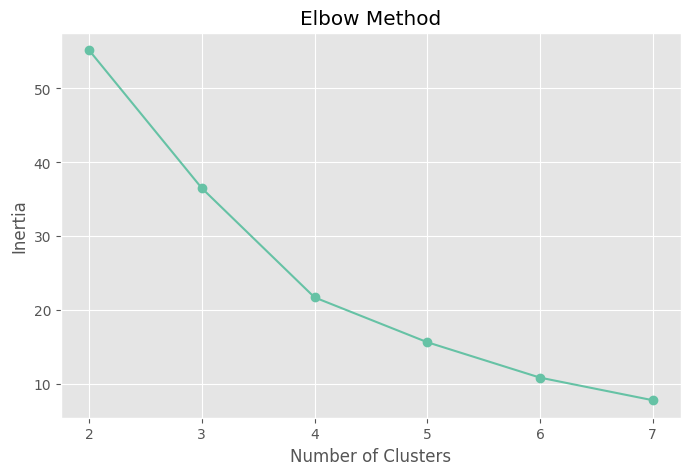

In [135]:
plt.figure(figsize=(8,5))

plt.plot(

    range(2,8),

    inertia,

    marker="o"

)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [136]:
# The Elbow Method indicates that 4 clusters provide the optimal balance between minimizing inertia and avoiding unnecessary model complexity. 
# Beyond four clusters, the reduction in inertia becomes marginal, suggesting diminishing returns.

In [137]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(X)

cluster_df

,Sub-Category,TotalSales,AverageOrderValue,Volatility,YoYGrowth,OrderCount,Cluster
0,Bookcases,113813.1987,503.598224,2220.405080,23.806516,226,0
1,Chairs,322822.7310,531.833165,4407.232960,7.135790,607,2
2,Labels,12347.7260,34.587468,223.471218,12.192651,357,0
3,Tables,202810.6280,645.893720,3224.082504,16.410685,314,2
4,Storage,219343.3920,263.633885,2822.084310,13.179873,832,2
5,Furnishings,89212.0180,95.823865,1360.017867,28.788938,931,0
6,Art,26705.4100,34.019631,330.488343,16.605553,785,0
7,Phones,327782.4480,374.180877,4052.718221,12.340878,876,2
8,Binders,200028.7850,134.067550,3848.223648,21.873607,1492,2
9,Appliances,104618.4030,227.926804,1821.621539,39.927584,459,0


In [138]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

cluster_df["PC1"] = X_pca[:,0]
cluster_df["PC2"] = X_pca[:,1]

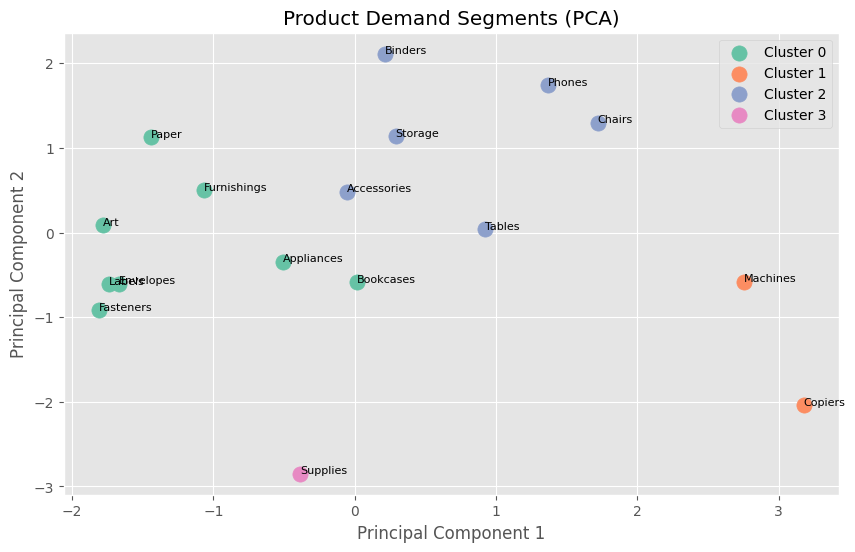

In [139]:
plt.figure(figsize=(10,6))

for cluster in sorted(cluster_df["Cluster"].unique()):

    temp = cluster_df[cluster_df["Cluster"] == cluster]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        s=120,
        label=f"Cluster {cluster}"
    )

    for _, row in temp.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            row["Sub-Category"],
            fontsize=8
        )

plt.title("Product Demand Segments (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

In [140]:
cluster_summary = (
    cluster_df
    .groupby("Cluster")
    .agg({
        "TotalSales":"mean",
        "AverageOrderValue":"mean",
        "Volatility":"mean",
        "YoYGrowth":"mean",
        "OrderCount":"mean"
    })
)

cluster_summary.round(2)

,TotalSales,AverageOrderValue,Volatility,YoYGrowth,OrderCount
Cluster,,,,,
0,55331.88,129.05,907.22,19.96,569.75
1,167743.36,1930.72,5552.16,46.34,90.50
2,239495.78,361.13,3489.06,18.10,812.83
3,46420.31,252.28,2025.09,192.84,184.00


In [141]:
# pending ........

## Task - 7

In [142]:
# import joblib

In [143]:
# joblib.dump(model,"models/xgboost_model.pkl")
# joblib.dump(scaler,"models/scaler.pkl")
# joblib.dump(kmeans,"models/kmeans.pkl")

['models/kmeans.pkl']

In [144]:
# cluster_df.to_csv(
#     "data/cluster_results.csv",
#     index=False
# )
# weekly_sales.to_csv(
#     "data/weekly_sales.csv",
#     index=False
# )
# monthly_sales.to_csv(
#     "data/monthly_sales.csv",
# #     index=False
# )

In [148]:
forecast_df = pd.DataFrame({
    "Segment":[
        "Furniture","Furniture","Furniture",
        "Technology","Technology","Technology",
        "Office Supplies","Office Supplies","Office Supplies",
        "West","West","West",
        "East","East","East"
    ],

    "Month":[
        "Jan 2019","Feb 2019","Mar 2019"
    ]*5,

    "Forecast":[
        furniture_forecast[0], furniture_forecast[1], furniture_forecast[2],
        technology_forecast[0], technology_forecast[1], technology_forecast[2],
        office_forecast[0], office_forecast[1], office_forecast[2],
        west_forecast[0], west_forecast[1], west_forecast[2],
        east_forecast[0], east_forecast[1], east_forecast[2]
    ]
})

forecast_df.to_csv(
    "data/forecast_results.csv",
    index=False
)

In [149]:
metrics = pd.DataFrame({

    "Model":["XGBoost"],

    "MAE":[14763.81],

    "RMSE":[18337.41],

    "MAPE":[14.48]

})

metrics.to_csv(
    "data/metrics.csv",
    index=False
)

In [151]:
weekly_sales.dtypes

Order Date     datetime64[ns]
Sales                 float64
Anomaly                 int32
RollingMean           float64
RollingStd            float64
Z                     float64
Z_Anomaly                bool
dtype: object